# 06a: Customer Churn Prediction with Logistic Regression

**RetailPulse AI Platform** • *Dedicated Classification Model*

### Model Scope:
- Ingest leak-free customer behavioral signals.
- Stratified 80/20 train/test holdout.
- Train Logistic Regression.
- Compute full classification stats:
  - **Confusion Matrix** (True Positives, False Positives, True Negatives, False Negatives)
  - **Classification Report** (Precision, Recall, F1 for Active and Churned classes)
  - **AUC-ROC Score**
  - **Precision @ Top 20% Highest Risk**
- Render visual Confusion Matrix heatmap and ROC Curve.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_score

churn_path = os.path.join('..', '..', 'data', 'processed', 'churn_features.csv')
df = pd.read_csv(churn_path)

feature_cols = [
    'total_orders', 'total_quantity', 'avg_quantity_per_line',
    'total_spend', 'avg_order_value', 'unique_products_bought',
    'weekend_purchase_ratio', 'days_as_customer',
    'purchase_frequency_days', 'F_Score', 'M_Score'
]

X = df[feature_cols].copy()
y = df['is_churned'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

if True:
    scaler = StandardScaler()
    X_train_proc = scaler.fit_transform(X_train)
    X_test_proc = scaler.transform(X_test)
else:
    X_train_proc = X_train
    X_test_proc = X_test
    
print(f'Training size: {len(X_train):,}, Test size: {len(X_test):,}')

Training size: 4,702, Test size: 1,176


In [2]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_proc, y_train)

y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

# Precision @ Top 20%
top_20_cutoff = int(len(y_test) * 0.20)
top_20_idx = np.argsort(y_prob)[-top_20_cutoff:]
p_top20 = precision_score(y_test[top_20_idx], np.ones(top_20_cutoff))
auc = roc_auc_score(y_test, y_prob)

print('========================================')
print(f'LOGISTIC REGRESSION CLASSIFIER STATS:')
print('========================================')
print(f'Area Under ROC Curve (AUC-ROC): {auc:.4f} (Target: >= 0.88)')
print(f'Precision @ Top 20% Highest Risk: {p_top20:.4f} (Target: >= 0.75)')
print('========================================\n')
print('CLASSIFICATION REPORT:')
print(classification_report(y_test, y_pred, target_names=['Active (0)', 'Churned (1)']))

LOGISTIC REGRESSION CLASSIFIER STATS:
Area Under ROC Curve (AUC-ROC): 0.7935 (Target: >= 0.88)
Precision @ Top 20% Highest Risk: 0.8043 (Target: >= 0.75)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Active (0)       0.74      0.66      0.70       578
 Churned (1)       0.71      0.78      0.74       598

    accuracy                           0.72      1176
   macro avg       0.73      0.72      0.72      1176
weighted avg       0.72      0.72      0.72      1176



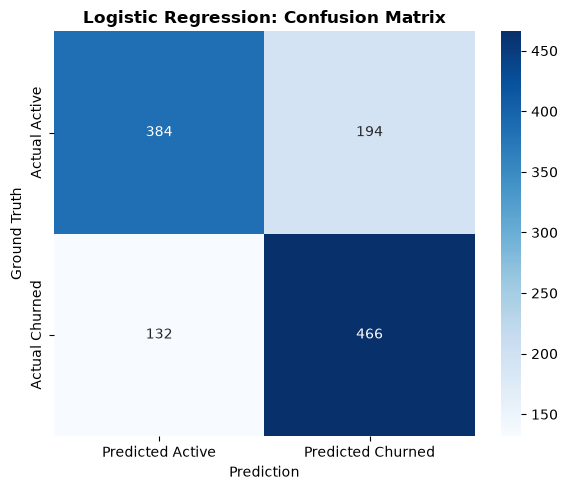

Confusion Matrix Breakdown: True Negatives=384, False Positives=194, False Negatives=132, True Positives=466


In [3]:
# 1. Visual Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Active', 'Predicted Churned'],
    yticklabels=['Actual Active', 'Actual Churned']
)
plt.title('Logistic Regression: Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.show()

print(f'Confusion Matrix Breakdown: True Negatives={tn}, False Positives={fp}, False Negatives={fn}, True Positives={tp}')

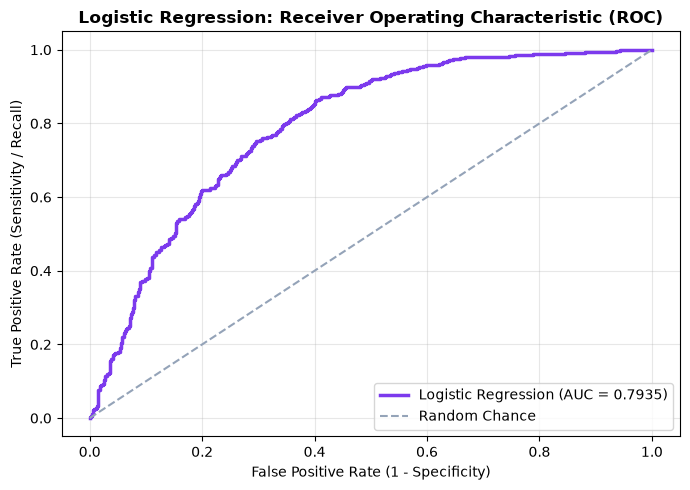

In [4]:
# 2. ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#7C3AED', lw=2.5, label='Logistic Regression (AUC = ' + str(round(auc, 4)) + ')')
plt.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', label='Random Chance')
plt.title('Logistic Regression: Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Coefficients Interpretation
Examining logistic regression weights to understand directional drivers of customer churn.

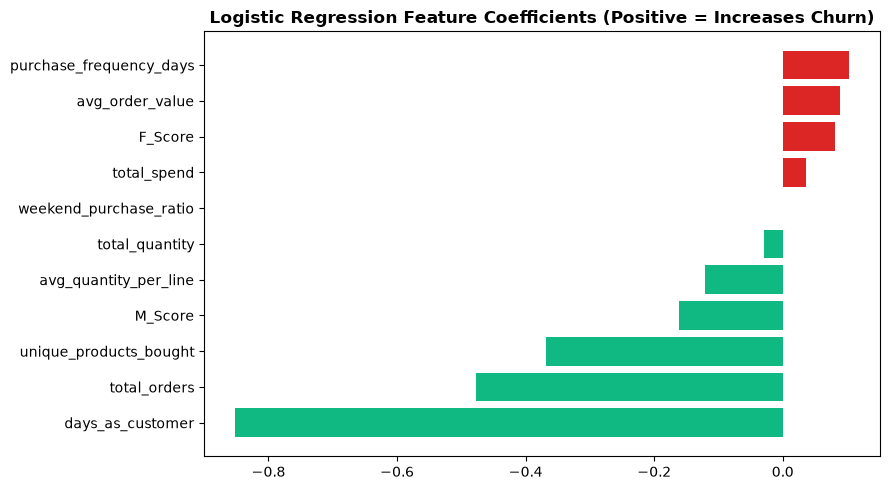

In [5]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_[0]}).sort_values('Coefficient')
plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=np.where(coef_df['Coefficient'] > 0, '#DC2626', '#10B981'))
plt.title('Logistic Regression Feature Coefficients (Positive = Increases Churn)', fontweight='bold')
plt.tight_layout()
plt.show()